<a href="https://colab.research.google.com/github/codewithtrisha09/ML-LAB/blob/main/WEEK_05_LOGISTIC_REGRESSION_AND_STOCHASTIC_GD_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1)Create a CSV file for the above training data and write a Python function program to find the fitted linear
regression with gradient descent technique. Compare the coefficients obtained from the sklearn model with
your program. Compute the log loss, MSE and RMSE. Plot the graph Daughter height (Y-axis) vs Mother
height (X-axis) with blue colour. Also, plot the line of best fit with red colour. Predict her daughter’s height
with given a new mother height as 63. Plot the graph of error in y-axis and iteration in x-axis with 4 epochs
(6x4=24 iterations).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
X=np.array([58,62,60,64,67,70])
Y=np.array([60,60,58,60,70,72])
np.savetxt("height_data.csv", np.column_stack((X, Y)), delimiter=",", header="mother_height,daughter_height", comments="")
m,c=0.0,0.0
L=0.002
epochs=4
steps_per_epoch=6
total_iterations=epochs*steps_per_epoch
errors = []
n = len(X)
for i in range(total_iterations):
    Y_pred=m*X+c
    mse = np.mean((Y - Y_pred) ** 2)
    errors.append(mse)
    dm=(-2/n)*np.sum(X*(Y-Y_pred))
    dc=(-2/n)*np.sum(Y-Y_pred)
    m-=L*dm
    c-=L*dc

Y_final_pred = m * X + c
final_mse = np.mean((Y - Y_final_pred) ** 2)
final_rmse = np.sqrt(final_mse)
eps=1e-15

clamped_pred = np.clip(Y_final_pred / np.max(Y), eps, 1 - eps)
clamped_true = np.clip(Y / np.max(Y), eps, 1 - eps)
pseudo_log_loss = -np.mean(clamped_true * np.log(clamped_pred) + (1 - clamped_true) * np.log(1 - clamped_pred))


print("Question 1: Linear Regression")
print(f"Custom GD Coefficients => ")
print(f"Slope (m): {m:.4f}, Intercept (c): {c:.4f}")
print(f"MSE: {final_mse:.4f}")
print(f"RMSE: {final_rmse:.4f}")
print(f"Pseudo Log Loss: {pseudo_log_loss:.4f}")






Question 1: Linear Regression
Custom GD Coefficients => 
Slope (m): -23062235669218412325647679488.0000, Intercept (c): -361697636212024088400494592.0000
MSE: 2154499189240351500195035439403073599734797765870738227593216.0000
RMSE: 1467821238857222575808957120512.0000
Pseudo Log Loss: 30.3813


In [ ]:
new_mother_height = 63.0
predicted_daughter_height = m * new_mother_height + c
print(f"Predicted height for mother (63): {predicted_daughter_height:.4f}")


Predicted height for mother (63): -1453282544796971947896365645824.0000


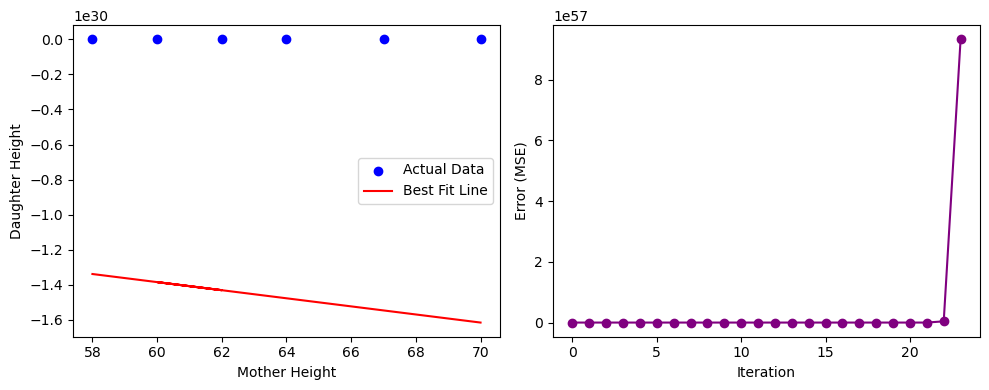

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color="blue", label="Actual Data")
plt.plot(X, Y_final_pred, color="red", label="Best Fit Line")
plt.xlabel("Mother Height")
plt.ylabel("Daughter Height")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(total_iterations), errors, color="purple", marker='o')
plt.xlabel("Iteration")
plt.ylabel("Error (MSE)")
plt.tight_layout()
plt.show()

Q2)Create a CSV file for the above training data and write a Python function program to find the fitted logistic
regression with gradient descent technique. Compare the coefficients obtained from the sklearn model with
your program. Compute the predicted y and assign the class label (prediction = 0 IF p(fail) < 0.5 and prediction
= 1 IF p(pass) >= 0.5) and compute the accuracy. Find the error for each iteration and predict the probability
that a student will pass the exam if they study for a) 3.5 hours b) 7.5 hours. Plot the graph of error in y-axis
and iteration in x-axis with 3 epochs (8x3=24 iterations).

In [ ]:
X_log=np.array([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0])
Y_log=np.array([0,0,0,0,1,1,1,1])
np.savetxt("logistic_data.csv", np.column_stack((X_log, Y_log)), delimiter=",", header="hours,pass", comments="")
def sigmoid(z):
    return 1/(1+np.exp(-z))
w,b=0.0,0.0
L=0.1
epochs=3
steps_per_epoch=8
total_iterations=epochs*steps_per_epoch
log_errors=[]
n_samples=len(X_log)

for i in range(total_iterations):
    z = w * X_log + b
    p = sigmoid(z)
    eps=1e-15
    p = np.clip(p, eps, 1 - eps)
    loss = -np.mean(Y_log * np.log(p) + (1 - Y_log) * np.log(1 - p))
    log_errors.append(loss)
    dw=(1/n_samples)*np.sum((p-Y_log)*X_log)
    db=(1/n_samples)*np.sum(p-Y_log)
    m-=L*dw
    c-=L*db

final_z = w * X_log + b
final_p = sigmoid(final_z)
predictions = (final_p >= 0.5).astype(int)
accuracy = np.mean(predictions == Y_log)


print("\nQuestion 2: Binary Logistic Regression")
print(f"Custom GD Coefficients => Weight: {w:.4f}, Bias: {b:.4f}")
print(f"Model Predictions: {predictions}")
print(f"Accuracy:{accuracy*100:.2f}%")


Question 2: Binary Logistic Regression
Custom GD Coefficients => Weight: 0.0000, Bias: 0.0000
Model Predictions: [1 1 1 1 1 1 1 1]
Accuracy:50.00%


In [ ]:

prob_35 =sigmoid(w*3.5 + b)
prob_75 =sigmoid(w*7.5 + b)
print(f"Probability of passing with 3.5 hours:{prob_35:.4f}")
print(f"Probability of passing with 7.5 hours:{prob_75:.4f}")


Probability of passing with 3.5 hours:0.5000
Probability of passing with 7.5 hours:0.5000


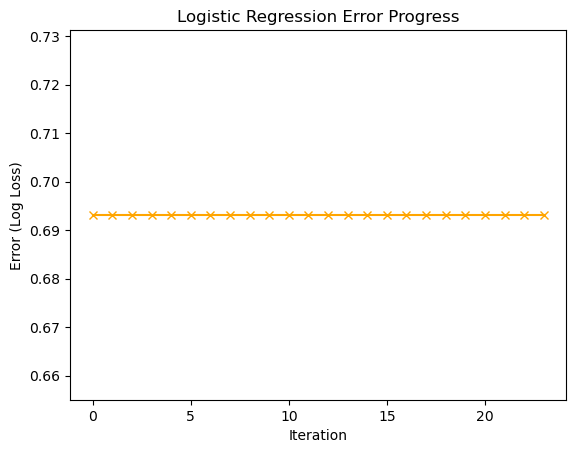

In [ ]:
plt.figure()
plt.plot(range(total_iterations), log_errors, color="orange", marker='x')
plt.xlabel("Iteration")
plt.ylabel("Error (Log Loss)")
plt.title("Logistic Regression Error Progress")
plt.show()


3.
x1 x2 y
1) 4 1 2
2) 2 8 -14
3) 1 0 1
4) 3 2 -1
5) 1 4 -7
6) 6 7 -8
Consider the above dataset with two independent variables (X1 and X2) and a dependent variable (Y).
Implement in python, how you can perform the logistic regression to model the relationship between the
independent variables and the dependent variable

In [ ]:
X_multi=np.array([[4,1],[2,8],[1,0],[3,2],[1,4],[6,7]])
Y_raw = np.array([2, -14, 1, -1, -7, -8])
Y_multi = (Y_raw > 0).astype(int)

weights = np.zeros(X_multi.shape[1])
bias = 0.0
L = 0.05
iterations = 100
n_samples = len(Y_multi)

In [ ]:
for _ in range (iterations):
    z=np.dot(X_multi,weights)+bias
    p=sigmoid(z)
    dw = (1 / n_samples) * np.dot(X_multi.T, (p - Y_multi))
    db = (1 / n_samples) * np.sum(p - Y_multi)
    weights-=L*dw
    bias-=L*db
print("\nQuestion 3:Multi-Variate Logistic Regression")
print(f"Calculated Weights (w1, w2): {weights}")
print(f"Calculated Bias (b): {bias:.4f}")




Question 3:Multi-Variate Logistic Regression
Calculated Weights (w1, w2): [ 0.7205008  -1.83983466]
Calculated Bias (b): 0.5095


In [ ]:

final_probabilities = sigmoid(np.dot(X_multi, weights) + bias)
print("Calculated element probabilities:\n")
print(f"{final_probabilities}")


Calculated element probabilities:

[8.25158431e-01 2.85011308e-06 7.73823373e-01 2.67246032e-01
 2.17334696e-03 3.20178660e-04]


ADDITIONAL QUESTIONS

Q1

In [ ]:
import numpy as np

data = {
    "Year": list(range(1981, 2023)),
    "Gold_Price": [
        1800, 1645, 1800, 1970, 2130, 2140, 2570, 3130, 3140, 3200,
        3466, 4334, 4140, 4598, 4680, 5160, 4725, 4045, 4234, 4400,
        4300, 4990, 5600, 5850, 7000, 8400, 10800, 12500, 14500, 18500,
        26400, 31050, 29600, 28006, 26343, 28623, 29667, 31438, 35220,
        48651, 50045, 52950
    ],
    "Silver_Price": [
        2715, 2720, 3105, 3570, 3955, 4015, 4794, 6066, 6755, 6463,
        6646, 8040, 5489, 7124, 6335, 7346, 7345, 8560, 7615, 7900,
        7215, 7875, 7695, 11770, 10675, 17405, 19520, 23625, 22165, 27255,
        56900, 56290, 54030, 43070, 37825, 36990, 37825, 41400, 40600,
        63435, 62572, 55100
    ]
}

years = np.array(data["Year"], dtype=float)
gold_per_gram = np.array(data["Gold_Price"], dtype=float) / 10.0
silver_per_gram=np.array(data["Silver_Price"],dtype=float) / 1000.0
def ols_linear_regression(X,Y):
    n=len(X)
    m=(n*np.sum(X*Y)-np.sum(X)*np.sum(Y))/(n*np.sum(X**2)-(np.sum(X))**2)
    c=(np.sum(Y)-m*np.sum(X))/n
    return m,c
m_gold_ols, c_gold_ols = ols_linear_regression(years, gold_per_gram)
m_silver_ols, c_silver_ols = ols_linear_regression(years, silver_per_gram)
mean_x,std_x=np.mean(years),np.std(years)
X_norm=(years-mean_x)/std_x

def train_sgd(X_scaled, Y_target, lr=0.005, epochs=1500):
    w, b = 0.0, 0.0
    n = len(Y_target)
    np.random.seed(42)

    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)
        for idx in indices:
            x_i = X_scaled[idx]
            y_i = Y_target[idx]

            y_pred = w * x_i + b
            dw = -2 * x_i * (y_i - y_pred)
            db = -2 * (y_i - y_pred)

            w -= lr * dw
            b -= lr * db
    w_orig=w/std_x
    b_orig=b-(w*mean_x/std_x)
    return w_orig,b_orig

m_gold_sgd, c_gold_sgd = train_sgd(X_norm, gold_per_gram)
m_silver_sgd, c_silver_sgd = train_sgd(X_norm, silver_per_gram)
gold_preds = m_gold_sgd * years + c_gold_sgd
residual_errors = gold_per_gram - gold_preds
mse_gold = np.mean(residual_errors ** 2)
rmse_gold = np.sqrt(mse_gold)

pred_gold_2024 = m_gold_sgd * 2024 + c_gold_sgd
pred_gold_2025 = m_gold_sgd * 2025 + c_gold_sgd
pred_silver_2024 = m_silver_sgd * 2024 + c_silver_sgd



In [ ]:

print("1. COEFFICIENT COMPARISONS ")
print(f"Gold  [Pure OLS Benchmark] -> Slope: {m_gold_ols:.4f}, Intercept: {c_gold_ols:.4f}")
print(f"Gold  [Custom SGD Engine]   -> Slope: {m_gold_sgd:.4f}, Intercept: {c_gold_sgd:.4f}")
print(f"Silver[Pure OLS Benchmark] -> Slope: {m_silver_ols:.4f}, Intercept: {c_silver_ols:.4f}")
print(f"Silver[Custom SGD Engine]   -> Slope: {m_silver_sgd:.4f}, Intercept: {c_silver_sgd:.4f}")
print("\n")
print("2. PERFORMANCE METRICS (GOLD) ")
print(f"Mean Squared Error (MSE): {mse_gold:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gold:.4f}")
print("\n")
print("3. 1-GRAM FUTURE TARGET PRICE PREDICTIONS")
print(f"Gold Price (2024 Prediction)  : Rs {pred_gold_2024:.2f}")
print(f"Gold Price (2025 Prediction)  : Rs {pred_gold_2025:.2f}")
print(f"Silver Price (2024 Prediction): Rs {pred_silver_2024:.2f}")


1. COEFFICIENT COMPARISONS 
Gold  [Pure OLS Benchmark] -> Slope: 104.8102, Intercept: -208401.9988
Gold  [Custom SGD Engine]   -> Slope: 104.3340, Intercept: -207450.9626
Silver[Pure OLS Benchmark] -> Slope: 1.3887, Intercept: -2759.1509
Silver[Custom SGD Engine]   -> Slope: 1.3825, Intercept: -2746.7622


2. PERFORMANCE METRICS (GOLD) 
Mean Squared Error (MSE): 523704.0556
Root Mean Squared Error (RMSE): 723.6740


3. 1-GRAM FUTURE TARGET PRICE PREDICTIONS
Gold Price (2024 Prediction)  : Rs 3721.07
Gold Price (2025 Prediction)  : Rs 3825.40
Silver Price (2024 Prediction): Rs 51.47


In [ ]:
import numpy as np

X_log = (years - np.mean(years)) / np.std(years)
Y_log = np.array([1 if gold_per_gram[i] >= gold_per_gram[i-1] else 0 for i in range(len(gold_per_gram))])
Y_log[0] = 1

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def run_logistic_bgd(X, Y, lr=0.1, epochs=500):
    w, b = 0.0, 0.0
    n = len(Y)
    for epoch in range(epochs):
        z = w * X + b
        p = sigmoid(z)
        dw = (1 / n) * np.sum((p - Y) * X)
        db = (1 / n) * np.sum(p - Y)
        w -= lr * dw
        b -= lr * db
    return w, b
def run_logistic_sgd(X, Y, lr=0.05, epochs=500):
    w, b = 0.0, 0.0
    n = len(Y)
    np.random.seed(42)
    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)
        for idx in indices:
            x_i = X[idx]
            y_i = Y[idx]
            z_i = w * x_i + b
            p_i = sigmoid(z_i)
            dw = (p_i - y_i) * x_i
            db = (p_i - y_i)
            w -= lr * dw
            b -= lr * db
    return w, b

w_bgd, b_bgd = run_logistic_bgd(X_log, Y_log)
w_sgd, b_sgd = run_logistic_sgd(X_log, Y_log)

print("\nLOGISTIC REGRESSION TEMPLATE RESULTS")
print(f"BGD Weight: {w_bgd:.4f}, BGD Bias: {b_bgd:.4f}")
print(f"SGD Weight: {w_sgd:.4f}, SGD Bias: {b_sgd:.4f}")



LOGISTIC REGRESSION TEMPLATE RESULTS
BGD Weight: -0.0127, BGD Bias: 1.4465
SGD Weight: 0.0059, SGD Bias: 1.4499


Q2

In [ ]:
import math

data = {
    "Year": list(range(1981, 2023)),
    "Gold_Price": [
        1800, 1645, 1800, 1970, 2130, 2140, 2570, 3130, 3140, 3200,
        3466, 4334, 4140, 4598, 4680, 5160, 4725, 4045, 4234, 4400,
        4300, 4990, 5600, 5850, 7000, 8400, 10800, 12500, 14500, 18500,
        26400, 31050, 29600, 28006, 26343, 28623, 29667, 31438, 35220,
        48651, 50045, 52950
    ],
    "Silver_Price": [
        2715, 2720, 3105, 3570, 3955, 4015, 4794, 6066, 6755, 6463,
        6646, 8040, 5489, 7124, 6335, 7346, 7345, 8560, 7615, 7900,
        7215, 7875, 7695, 11770, 10675, 17405, 19520, 23625, 22165, 27255,
        56900, 56290, 54030, 43070, 37825, 36990, 37825, 41400, 40600,
        63435, 62572, 55100
    ]
}

X = data["Gold_Price"][1:]
Y = []
for i in range(1, len(data["Silver_Price"])):
    if data["Silver_Price"][i] > data["Silver_Price"][i-1]:
        Y.append(1)
    else:
        Y.append(0)

x_min, x_max = min(X), max(X)
X_scaled = [(x - x_min) / (x_max - x_min) for x in X]

learning_rate = 0.5
epochs = 2000
w = 0.0
b = 0.0
m = len(X_scaled)

def sigmoid(z):
    return 1.0 / (1.0 + math.exp(-z))

for epoch in range(epochs):
    dw = 0.0
    db = 0.0

    for i in range(m):

        z = w * X_scaled[i] + b
        y_pred = sigmoid(z)

        error = y_pred - Y[i]

        dw += error * X_scaled[i]
        db += error

    w -= learning_rate * (dw / m)
    b -= learning_rate * (db / m)

print(f"Training Finished ")
print(f"Learned Weight (w): {w:.4f}")
print(f"Learned Bias (b): {b:.4f}")

test_gold_price = 45000
test_scaled = (test_gold_price - x_min) / (x_max - x_min)
probability = sigmoid(w * test_scaled + b)
prediction = 1 if probability >= 0.5 else 0

print(f"\nPrediction Example")
print(f"Target Gold Price: {test_gold_price}")
print(f"Probability that Silver Price will increase: {probability:.2%}")
print(f"Predicted Direction: {'INCREASE (1)' if prediction == 1 else 'DECREASE/STAGNANT (0)'}")


Training Finished 
Learned Weight (w): -2.4027
Learned Bias (b): 0.9356

Prediction Example
Target Gold Price: 45000
Probability that Silver Price will increase: 25.07%
Predicted Direction: DECREASE/STAGNANT (0)
